# Real, and worth acting on?

**Week 1, Thursday. Chapter 2 of 6.** By the end of this notebook you can size a real gap in rupees
against the segment, the company and the cost of acting, keep "significant" and "important" in two
separate sentences, and read a bootstrap range as the second route.

> **The client asks.** "So my tier really is slipping. What do I get to fix it?"
>
> The head of Retail-Plus, before the growth review

**The metric at stake.** The same delivered revenue per member, now multiplied out to rupees a
quarter. **Who asks and what rides on it.** The head of Retail-Plus wants a retention budget, and
Meera has to weigh it against every other line in the quarter: fund a Rs 11,000 offer that cannot
pay back and the money is gone; ignore a fall that is growing and the tier drains. **Who else faces
it.** At Microsoft, a small change to how Bing showed ad headlines raised revenue by 12 percent,
more than 100 million dollars a year in the United States alone, while the company's own
researchers found that only about a third of experiments built to improve a metric did improve it.
Size in money, beside the share, is what told one change from the rest.

Chapter 1 established that the Retail-Plus fall, Rs 1,110 per member, is bigger than the usual
wobble, and the textbook test agreed. This chapter adds two helpers: `delivered`, a segment's
revenue in a quarter, and `bootstrap_gaps`, the range the second route reads.

**Setup.** The toolkit from chapter 1, plus the two new helpers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import time

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)                  # the same shuffles on every laptop
    pool = q1 + q2                     # all the cards, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)           # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """The share of chance-only worlds whose gap is at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """Redraw each quarter's members with replacement, many times, and keep each gap."""
    random.seed(seed)
    return [mean([random.choice(q1) for _ in q1]) - mean([random.choice(q2) for _ in q2])
            for _ in range(times)]

plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
real = mean(plus_q1) - mean(plus_q2)
print(f"{len(plus_q1)} Retail-Plus members; gap Rs {real:,.0f} per member, carried from chapter 1")

22 Retail-Plus members; gap Rs 1,110 per member, carried from chapter 1


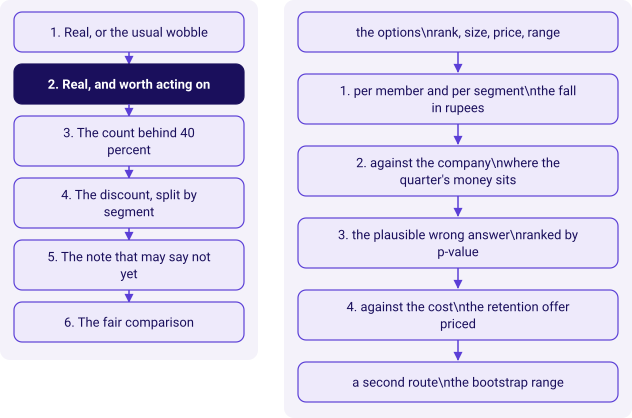

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=1, show=False),
    kit.vflow(['the options\\nrank, size, price, range', '1. per member and per segment\\nthe fall in rupees', "2. against the company\\nwhere the quarter's money sits", '3. the plausible wrong answer\\nranked by p-value', '4. against the cost\\nthe retention offer priced', 'a second route\\nthe bootstrap range'], show=False),
)

## The options

Four ways a team could answer "is it worth acting on?"

| Option | What it does | What it misses |
|---|---|---|
| A. Rank by p-value | Test every segment and fix the smallest share first | Size: a share says how sure, never how big |
| B. Size against the segment | The fall as a share of the tier's own revenue | The company: a third of a small tier can be a rounding error for Meera |
| C. Size against the company and the cost | The fall in rupees beside the quarter and beside what a fix costs, with its break-even | Nothing the decision needs, if the cost is known |
| D. A range for the fall | Redraw the members many times and read how small or large the fall could be | Nothing, and it answers a sharper question than C alone |

Option,Rows it touches,Time on this file,What it risks
A. Rank by p-value,"3 segments x 5,000 shuffles",about a second,reads the smallest share as the biggest money
B. Against the segment,the tier's 2 quarters,instant,reads a third of the tier as a crisis
C. Against company and cost,"186 orders, one pass",0.2 ms,needs a cost; today's is assumed
D. Bootstrap range,"44 member totals x 5,000 redraws",0.05 s,a stakeholder has to read a range


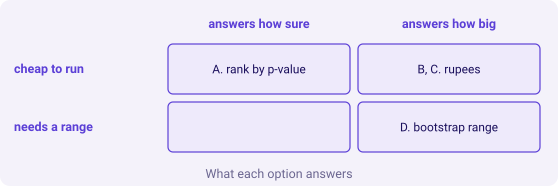

In [3]:
t0 = time.perf_counter()
company_q2 = sum(delivered(s, "Q2") for s in SEGMENTS)
t_c = time.perf_counter() - t0
t0 = time.perf_counter(); boot = bootstrap_gaps(plus_q1, plus_q2, 5000, seed=2026); t_d = time.perf_counter() - t0
rows = [
    ("A. Rank by p-value", "3 segments x 5,000 shuffles", "about a second", "reads the smallest share as the biggest money"),
    ("B. Against the segment", "the tier's 2 quarters", "instant", "reads a third of the tier as a crisis"),
    ("C. Against company and cost", f"{len(ORDERS)} orders, one pass", f"{t_c * 1000:.1f} ms", "needs a cost; today's is assumed"),
    ("D. Bootstrap range", "44 member totals x 5,000 redraws", f"{t_d:.2f} s", "a stakeholder has to read a range"),
]
kit.table(["Option", "Rows it touches", "Time on this file", "What it risks"], rows,
          caption="The options sized on Kalpa's file")
kit.matrix(["cheap to run", "needs a range"], ["answers how sure", "answers how big"],
           [["A. rank by p-value", "B, C. rupees"], ["", "D. bootstrap range"]],
           title="What each option answers")
kit.check("every option runs in under five seconds here", max(t_c, t_d) < 5)

**The best-fit call: C, with D as the second route.** Meera's decision is a budget line, so the
answer has to be in rupees beside the company's quarter and beside the offer's cost, and the
break-even says what the offer must win back. D then asks whether the range of plausible falls
clears that break-even. **The fact that would change the call.** A known recovery rate from an
earlier retention offer: with it, C alone decides, and the range matters less.

## 1. The fall in rupees, per member and for the segment

A per-member gap is a rate. The budget holder needs the total: the gap times the members who exist
in both quarters.

**Predict before you run.** Retail-Plus lost Rs 1,110 per member. In total, per quarter, that is
roughly: a) Rs 2,400; b) Rs 24,000; c) Rs 2.4 lakh; d) Rs 24 lakh.

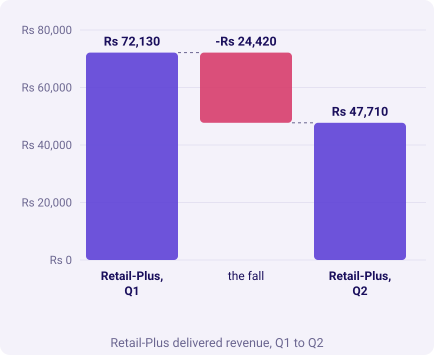

In [4]:
plus_fall = round(real * len(plus_q1))
kit.bridge(("Retail-Plus, Q1", sum(plus_q1)), [("the fall", -plus_fall)], end_label="Retail-Plus, Q2",
           title="Retail-Plus delivered revenue, Q1 to Q2")
kit.stats([(kit.rupees(real), "per member", "Q1 mean less Q2 mean"),
           (f"{len(plus_q1)}", "members", "in both quarters"),
           (kit.rupees(plus_fall), "a quarter", "the segment's fall")])
kit.check("Retail-Plus lost Rs 24,420 of delivered revenue in a quarter", plus_fall == 24420, kit.rupees(plus_fall))

**What happened.** The answer is b. Rs 1,110 times 22 members is Rs 24,420 a quarter: the tier
delivered Rs 72,130 in Q1 and Rs 47,710 in Q2. For the segment that is a third of its money, which is
why the head of Retail-Plus is worried.

## 2. Against the company's quarter

Meera runs the company, so the second size is the fall against the company's delivered revenue,
with every segment's move side by side.

**Predict before you run.** As a share of the company's Q2 delivered revenue, the Retail-Plus fall
is: a) about 30 percent; b) about 3 percent; c) under half of one percent; d) impossible to say
without Business.

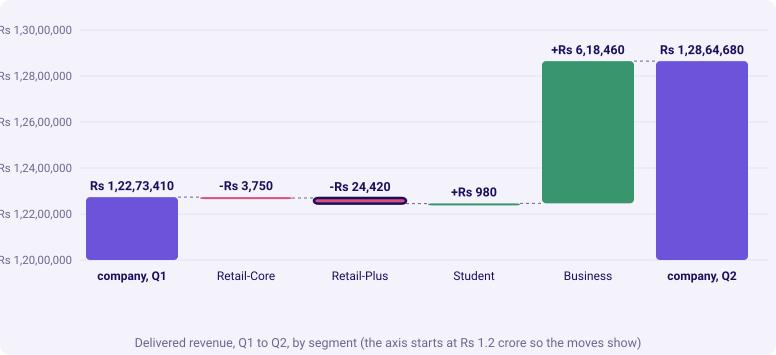

company delivered: Q1 Rs 1,22,73,410, Q2 Rs 1,28,64,680; the Retail-Plus fall is 0.19% of Q2


In [5]:
company_q1 = sum(delivered(s, "Q1") for s in SEGMENTS)
moves = [(s, delivered(s, "Q2") - delivered(s, "Q1")) for s in SEGMENTS]
kit.bridge(("company, Q1", company_q1), moves, end_label="company, Q2", lo=12_000_000, lit=[1],
           title="Delivered revenue, Q1 to Q2, by segment (the axis starts at Rs 1.2 crore so the moves show)")
share_of_company = plus_fall / company_q2
print(f"company delivered: Q1 {kit.rupees(company_q1)}, Q2 {kit.rupees(company_q2)}; "
      f"the Retail-Plus fall is {share_of_company:.2%} of Q2")
kit.check("the bridge lands: Q1 plus every segment's move is Q2", company_q1 + sum(m for _, m in moves) == company_q2)
kit.check("the Retail-Plus fall is under half of one percent of the company's Q2", share_of_company < 0.005,
          f"{share_of_company:.2%}")

**What happened.** The answer is c. The company delivered Rs 1,28,64,680 in Q2, and the
Retail-Plus fall is 0.19 percent of it. Business rose by Rs 6,18,460 in the same quarter, twenty-five
times the Retail-Plus fall. The fall is real and small against the company; both are true, and the
note needs both.

## 3. The plausible wrong answer

**The plausible wrong answer.** A hurried draft runs the shuffle on every segment with enough
members, sorts by the share, and names the smallest share the biggest problem. Student waits for
chapter 3.

In [6]:
ranked = []
for s in ["Retail-Core", "Retail-Plus", "Business"]:
    q1, q2 = member_totals(s, "Q1"), member_totals(s, "Q2")
    share = share_at_least(shuffle_gaps(q1, q2, 5000, seed=2026), mean(q1) - mean(q2))
    ranked.append((s, share, delivered(s, "Q2") - delivered(s, "Q1")))
ranked.sort(key=lambda r: r[1])
for n, (s, share, move) in enumerate(ranked, 1):
    print(f"  {n}. {s:12s} p = {share:.3f}")
print(f"Draft: '{ranked[0][0]} is our biggest problem; fund its retention programme first.'")

  1. Retail-Plus  p = 0.027
  2. Retail-Core  p = 0.345
  3. Business     p = 0.555
Draft: 'Retail-Plus is our biggest problem; fund its retention programme first.'


**Why it is wrong.** The share says how surely a move beats chance. It never says how big the move
is, and the draft ranked by the wrong column: a retention programme would be funded because a share
was small, before anyone asked how much money the fall is against the company or what fixing it
costs. **The check** puts the rupees beside the share, and an invented
example shows why the two columns can disagree so far: with enough orders, even a trivial gap beats
chance.

Segment,"p, a fall this large","Delivered revenue, Q2 less Q1"
Retail-Plus,0.027,"-Rs 24,420"
Retail-Core,0.345,"-Rs 3,750"
Business,0.555,"Rs 6,18,460"


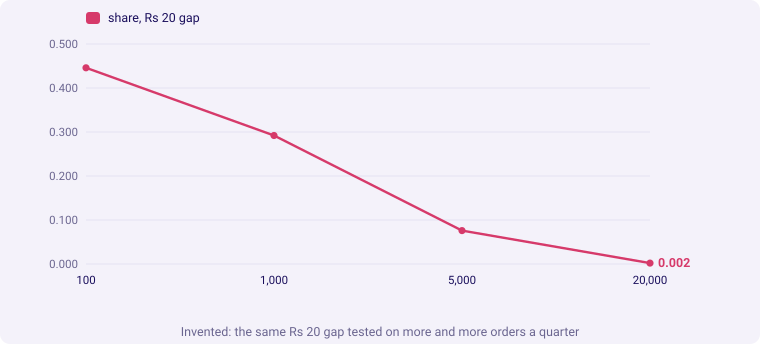

{100: 0.446, 1000: 0.292, 5000: 0.076, 20000: 0.002}


In [7]:
kit.table(["Segment", "p, a fall this large", "Delivered revenue, Q2 less Q1"],
          [(s, f"{share:.3f}", kit.rupees(move)) for s, share, move in ranked],
          caption="The same three segments with the money beside the share")
maker = random.Random(11)                                  # invented orders, a Rs 20 gap at every size
base = [maker.randint(1000, 3400) for _ in range(20000)]
sizes, shares = [100, 1000, 5000, 20000], []
for n in sizes:
    q2 = base[:n]
    shares.append(share_at_least(shuffle_gaps([v + 20 for v in q2], q2, 500, seed=2026), 20))
kit.line([f"{n:,}" for n in sizes], [("share, Rs 20 gap", shares, "bad")], fmt=lambda v: f"{v:.3f}",
         title="Invented: the same Rs 20 gap tested on more and more orders a quarter")
print(dict(zip(sizes, shares)))
kit.check("the segment with the smallest share moved under half of one percent of the company's Q2",
          abs(dict((s, m) for s, _, m in ranked)[ranked[0][0]]) / company_q2 < 0.005)
kit.check("an invented Rs 20 gap goes from chance-sized to significant on sample size alone",
          shares[0] > 0.2 and shares[-1] < 0.01, f"{shares}")

**The fix.** Two sentences where the draft had one, and any ranking done by money: "The
Retail-Plus fall is larger than the usual wobble. It is worth Rs 24,420 a quarter, 0.19 percent of
the company's delivered revenue, while Business moved Rs 6,18,460 the same quarter." What changed:
the size. By share Retail-Plus looked like the biggest problem; in rupees its fall is 0.19 percent of
the company's quarter, a twenty-fifth of the rise Business delivered, and the programme has to
justify itself against Rs 24,420 a quarter and the offer's cost, never against a share.

## 4. Against the cost: the retention offer priced

The head of Retail-Plus proposes a retention offer. **The cost is an assumption for this chapter,
since no Kalpa figure exists for it:** Rs 500 per member per quarter, offered to all 22 members.

**Predict before you run.** What share of the Rs 24,420 fall would the offer have to win back just
to pay for itself in revenue? a) all of it; b) about 45 percent; c) about 5 percent; d) none, since
any recovery is a gain.

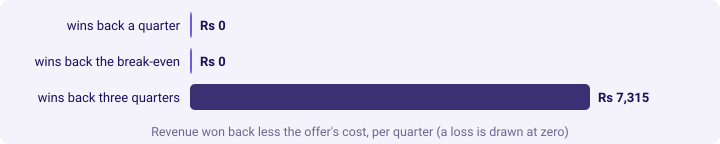

  wins back a quarter        net -Rs 4,895
  wins back the break-even   net Rs 0
  wins back three quarters   net Rs 7,315


In [8]:
offer_per_member = 500                                   # assumed for the chapter
offer_cost = offer_per_member * len(plus_q1)
break_even = offer_cost / plus_fall
scenarios = [("wins back a quarter", 0.25), ("wins back the break-even", break_even),
             ("wins back three quarters", 0.75)]
kit.bars([(label, max(0, round(plus_fall * r - offer_cost))) for label, r in scenarios], fmt=kit.rupees,
         lit=[2], title="Revenue won back less the offer's cost, per quarter (a loss is drawn at zero)")
for label, r in scenarios:
    print(f"  {label:26s} net {kit.rupees(round(plus_fall * r - offer_cost))}")
kit.check("the offer costs Rs 11,000 a quarter", offer_cost == 11000, kit.rupees(offer_cost))
kit.check("it pays only above a 45 percent recovery", round(break_even, 2) == 0.45, f"{break_even:.3f}")

**What happened.** The answer is b. The offer costs Rs 11,000 a quarter, so it has to win back 45
percent of the fall before it breaks even on revenue. Winning back a quarter loses about Rs 4,900;
winning back three quarters gains about Rs 7,300. The decision rests on a recovery rate nobody has
measured, which is what the note should say.

## A second route: the bootstrap range

Option D. The Rs 1,110 is one estimate from 22 members. Redraw each quarter's members with
replacement 5,000 times and read the middle 95 percent of the gaps. That range is called a
**confidence interval**; how to build one properly is a later week's topic, and today it arrives
as a picture.

**Predict before you run.** Does the range of plausible falls per member stay above zero, and does
it stay above the offer's Rs 500 per member? a) above both; b) above zero, and it dips below Rs 500;
c) below zero, so the fall may not be real; d) exactly Rs 1,110 every time.

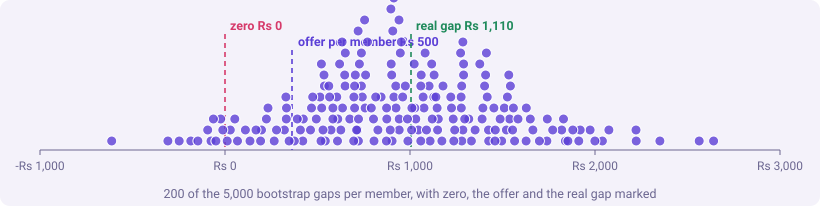

middle 95 percent: Rs 42 to Rs 2,192 per member, or Rs 920 to Rs 48,220 a quarter; share at or below zero 0.021


In [9]:
ordered = sorted(boot)
low, high = ordered[125], ordered[4874]
at_or_below_zero = sum(1 for g in boot if g <= 0) / len(boot)
kit.strip(boot[:200], markers=[("zero", 0, "bad"), ("offer per member", offer_per_member, "plain"),
                               ("real gap", real, "good")], lo=-1000, hi=3000,
          title="200 of the 5,000 bootstrap gaps per member, with zero, the offer and the real gap marked")
print(f"middle 95 percent: Rs {low:,.0f} to Rs {high:,.0f} per member, "
      f"or {kit.rupees(low * 22)} to {kit.rupees(high * 22)} a quarter; share at or below zero {at_or_below_zero:.3f}")
kit.check("the bootstrap range stays above zero, the same verdict as the shuffle", low > 0, f"{low:,.0f}")
kit.check("consistency: the share of redraws at or below zero sits near the shuffle's share",
          abs(at_or_below_zero - 0.027) < 0.01, f"{at_or_below_zero:.3f}")
kit.check("the range dips below the offer's Rs 500 per member", low < offer_per_member < high)

**What happened.** The answer is b. This approximate 95 percent range runs from about Rs 40 to Rs
2,200 per member (its low end moves by a few tens of rupees with the seed), so the fall is real by a
second route: the range stays above zero, and about 2 in 100 redraws land at or below zero, a
consistency check beside the shuffle's 0.027 rather than a second p-value, and it could be as small as about Rs 900 a quarter for the tier. The offer's Rs 500
per member sits inside the range, which is the arithmetic behind "test it on half the members
first". **When to switch.** Use the range whenever the decision has a cost to beat; the share alone
is enough only when the question is "real or not".

> **Kavya's review.** "Real, yes, by two routes. Worth Rs 24,420 a quarter, small against Business
> and a third of the tier. The range dips below what the offer costs, so do not fund it for all 22:
> offer it to half, hold back half, and measure. That is a watch item with a test attached, never a
> budget line."

### In the interview

**[F] A metric moved and the test says significant; how do you decide whether the business should
act?** "Significant only tells me the move is bigger than noise. To act I need three more things:
the size in money against the business and the segment, the cost of the action, and how much of
the gap the action could recover. If the break-even recovery is higher than anything we have seen,
or the range of the effect dips below the cost, I recommend a small test with a held-back group
rather than a rollout."

**[S] Explain a finding to a non-technical stakeholder.** "I lead with the decision the finding
supports, in one sentence, with one number and its denominator. Then the evidence, the caveat that
would change my view, and the action with what it costs. For example: Retail-Plus really is
spending less, about Rs 24,000 a quarter, which is a third of the tier and a fifth of one percent of
the company; an offer pays only if it wins back 45 percent, so test it on half the members first."

**[D] You can rank segments by p-value, by rupees or by rupees against the cost of fixing; which do
you take to the budget meeting, and what would change it?** "Rupees against the cost, because the
meeting decides money. The p-value only filters out noise. If a past offer had told me the recovery
rate, the break-even alone would decide, and I would skip the range."

### Depth: revenue is not margin

The break-even above compares the offer with revenue won back. Kalpa keeps only its margin on that
revenue, so the true break-even is higher. **The margin is an assumption for the depth section,
since no Kalpa margin figure exists:** at 30 percent, the offer would have to win back more than the
whole fall.

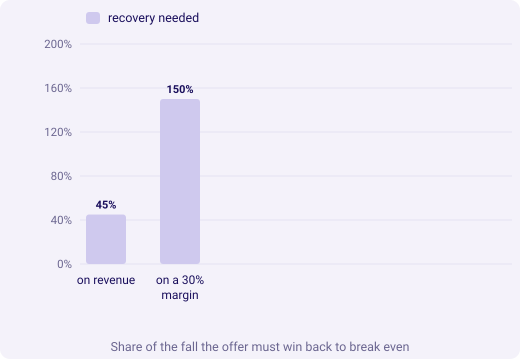

In [10]:
assumed_margin = 0.30                                    # assumed; no Kalpa figure exists
margin_break_even = offer_cost / (plus_fall * assumed_margin)
kit.columns(["on revenue", "on a 30% margin"], [("recovery needed", [round(break_even * 100), round(margin_break_even * 100)])],
            fmt=lambda v: f"{v:.0f}%", width=520, title="Share of the fall the offer must win back to break even")
kit.check("on an assumed 30 percent margin the offer cannot pay back from this fall", margin_break_even > 1,
          f"{margin_break_even:.0%}")

In [11]:
kit.check_summary()
print("Next: chapter 3. Student is up 40 percent; how many orders stand behind it?")

Next: chapter 3. Student is up 40 percent; how many orders stand behind it?
